# 🏁 Kaggle HBAAC 2026 — Demand Forecasting
**Approach:** Global LightGBM with lag/rolling features, Vietnamese holidays, and WRMSSE-aware evaluation.

**Prediction Horizon:**
- `_validation` rows → F1..F28 = 2025-09-06 to 2025-10-03
- `_evaluation` rows → F1..F28 = 2025-10-04 to 2025-10-31

**Metric:** WRMSSE (Weighted RMSSE, lower is better)

---
## 📦 Cell 1 — Install & Import Libraries

In [26]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

INPUT_DIR  = Path('/kaggle/input/competitions/hbaac-round2')
OUTPUT_DIR = Path('/kaggle/working')
TRAIN_PATH  = INPUT_DIR / 'train.csv'
SAMPLE_PATH = INPUT_DIR / 'sample_submission.csv'

TRAIN_START = pd.Timestamp('2020-11-17')
TRAIN_END   = pd.Timestamp('2025-09-05')
VAL_START   = pd.Timestamp('2025-09-06')
VAL_END     = pd.Timestamp('2025-10-03')
EVAL_START  = pd.Timestamp('2025-10-04')
EVAL_END    = pd.Timestamp('2025-10-31')
SPLIT_DATE  = pd.Timestamp('2025-07-12')
HORIZON     = 56
MIN_LAG     = 56
SEED        = 42
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 🗂️ Cell 2 — Load & Parse Raw Training Data

Column schema (from competition spec):
| Column | Spec type | Notes |
|:---|:---|:---|
| Date | YYYY-MM-DD | parse_dates |
| Stt | int | contains mixed values like 'T419036' → read as str |
| ItemCode | string | SKU code, e.g. SKU-08063 |
| Quantity | int | positive=sale, negative=return |
| UnitPrice | string (decimal ,) | VND, parse_vnd() required |
| SalesAmount | int | true int, can be negative |
| Unit Cost | string (decimal ,) | VND, parse_vnd() required |
| Cost Amount | int | true int, can be negative |

In [27]:
def parse_vnd(series: pd.Series) -> pd.Series:
    """Parse Vietnamese decimal-comma number strings to float.

    Examples:
        '123.559,1'  -> 123559.1   (thousands dot, decimal comma)
        '242,700'    -> 242700.0   (no thousands sep, comma as decimal? → actually 242700)
        '242700'     -> 242700.0   (plain integer)
        ''  / NaN    -> NaN

    Strategy:
        1. Remove all '.' (thousands separator)
        2. Replace ',' with '.'  (decimal separator)
        3. Cast to float
    """
    return (
        series
        .astype(str)
        .str.strip()
        .str.replace('.', '', regex=False)   # remove thousands separator
        .str.replace(',', '.', regex=False)  # decimal comma → decimal dot
        .replace({'nan': np.nan, '': np.nan})
        .astype(float)
    )


print('Reading train.csv ...')

# ── Dtype strategy per column ─────────────────────────────────────────────────
# • Stt         : read as str — documented int but contains non-numeric values
#                 like 'T419036' (return/special transaction codes)
# • ItemCode    : str — SKU codes are strings
# • Quantity    : NOT forced here — cast below with pd.to_numeric for safety
# • UnitPrice   : str — decimal-comma VND string, parsed with parse_vnd()
# • SalesAmount : NOT forced here — cast below
# • Unit Cost   : str — decimal-comma VND string, parsed with parse_vnd()
# • Cost Amount : NOT forced here — cast below

raw = pd.read_csv(
    TRAIN_PATH,
    dtype={
        'Stt':       'str',  # mixed int/string → keep as string, we don't use it
        'ItemCode':  'str',  # SKU strings like 'SKU-08063'
        'UnitPrice': 'str',  # decimal-comma format, parsed manually below
        'Unit Cost': 'str',  # decimal-comma format, parsed manually below
    },
    parse_dates=['Date'],
    low_memory=False
)

# ── Cast true integer columns after load ──────────────────────────────────────
# errors='coerce' → any remaining non-numeric values become NaN, then fill 0
raw['Quantity']    = pd.to_numeric(raw['Quantity'],    errors='coerce').fillna(0).astype('int32')
raw['SalesAmount'] = pd.to_numeric(raw['SalesAmount'], errors='coerce').fillna(0).astype('int64')
raw['Cost Amount'] = pd.to_numeric(raw['Cost Amount'], errors='coerce').fillna(0).astype('int64')

# ── Parse decimal-comma VND string columns ────────────────────────────────────
raw['UnitPrice'] = parse_vnd(raw['UnitPrice'])
raw['Unit Cost'] = parse_vnd(raw['Unit Cost'])

# ── Convert ItemCode to category for memory efficiency ────────────────────────
raw['ItemCode'] = raw['ItemCode'].astype('category')

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f'Raw rows      : {len(raw):,}')
print(f'SKUs          : {raw["ItemCode"].nunique():,}')
print(f'Date range    : {raw["Date"].min().date()} → {raw["Date"].max().date()}')
print(f'Quantity range: {raw["Quantity"].min()} to {raw["Quantity"].max()}  (neg = returns)')
print(f'Returns rows  : {(raw["Quantity"] < 0).sum():,}  ({(raw["Quantity"] < 0).mean()*100:.1f}%)')
print(f'\nDtypes after load:')
print(raw.dtypes.to_string())
raw.head(3)

Reading train.csv ...
Raw rows      : 711,980
SKUs          : 15,972
Date range    : 2020-11-17 → 2025-09-05
Quantity range: -998 to 5998  (neg = returns)
Returns rows  : 37,434  (5.3%)

Dtypes after load:
Date           datetime64[ns]
Stt                    object
ItemCode             category
Quantity                int32
UnitPrice             float64
SalesAmount             int64
Unit Cost             float64
Cost Amount             int64


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700.0000,2184300,123559.1000,1482709
1,2020-11-17,2000003,SKU-09458,600,131818.1818,79090909,110000.0000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000.0000,940909,101000.0000,606000


---
## 🔍 Cell 3 — Compute Per-SKU Profit Weights (for WRMSSE)

In [28]:
# Profit = SalesAmount − Cost Amount  (row-level, both are true integers, can be negative)
raw['Profit'] = raw['SalesAmount'].astype(float) - raw['Cost Amount'].astype(float)

sku_profit = (
    raw.groupby('ItemCode', observed=True)['Profit']
       .sum().reset_index().rename(columns={'Profit': 'total_profit'})
)
# Competition rule: negative total_profit → weight = 0
sku_profit['total_profit'] = sku_profit['total_profit'].clip(lower=0)
total = sku_profit['total_profit'].sum()
sku_profit['weight'] = sku_profit['total_profit'] / total if total > 0 else 0.0

print(f'SKUs with positive profit : {(sku_profit["total_profit"] > 0).sum():,}')
print(f'SKUs with zero profit     : {(sku_profit["total_profit"] == 0).sum():,}')
print(f'Total profit (VND)        : {total:,.0f}')
sku_profit.nlargest(10, 'weight')[['ItemCode', 'total_profit', 'weight']]

SKUs with positive profit : 14,139
SKUs with zero profit     : 1,833
Total profit (VND)        : 180,034,123,945


,ItemCode,total_profit,weight
2,SKU-00003,16700681088.0000,0.0928
1,SKU-00002,8012686409.0000,0.0445
9197,SKU-09458,2668406627.0000,0.0148
4,SKU-00005,2243340437.0000,0.0125
8354,SKU-08589,1287111640.0000,0.0071
12229,SKU-12534,1215803793.0000,0.0068
9492,SKU-09760,1200524689.0000,0.0067
12230,SKU-12537,1106799793.0000,0.0061
315,SKU-00324,979471964.0000,0.0054
13993,SKU-14323,967927091.0000,0.0054


---
## 🧹 Cell 4 — Handle Returns & Aggregate to Daily Grain

In [29]:
# Returns have negative Quantity, SalesAmount, Cost Amount.
# Strategy: aggregate daily (sum), so returns naturally offset same-day sales.
# After aggregation, clip net daily quantity to 0 (we forecast demand, not returns).
daily = (
    raw.groupby(['ItemCode', 'Date'], observed=True)
    .agg(
        Quantity=('Quantity', 'sum'),
        SalesAmount=('SalesAmount', 'sum'),
        CostAmount=('Cost Amount', 'sum'),
    )
    .reset_index()
)
# Clip: a net-negative day (returns > sales) is treated as 0 demand
daily['Quantity'] = daily['Quantity'].clip(lower=0)

print(f'Daily grain rows: {len(daily):,}')
print(f'Date range      : {daily["Date"].min().date()} → {daily["Date"].max().date()}')
daily.head(3)

Daily grain rows: 507,050
Date range      : 2020-11-17 → 2025-09-05


,ItemCode,Date,Quantity,SalesAmount,CostAmount
0,SKU-00001,2025-05-26,1,830368,0
1,SKU-00001,2025-05-27,1,1032840,0
2,SKU-00001,2025-05-28,2,2084484,0


---
## 📅 Cell 5 — Reindex to Full Daily Calendar for All SKUs

In [30]:
all_dates = pd.date_range(TRAIN_START, TRAIN_END, freq='D')
all_skus  = daily['ItemCode'].cat.categories if hasattr(daily['ItemCode'], 'cat') \
            else daily['ItemCode'].unique()
full_idx = pd.MultiIndex.from_product([all_skus, all_dates], names=['ItemCode', 'Date'])
print(f'Full grid: {len(full_idx):,} rows ({len(all_skus):,} SKUs × {len(all_dates):,} days)')

daily = (
    daily.set_index(['ItemCode', 'Date'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)
daily['ItemCode'] = daily['ItemCode'].astype('category')
daily['Quantity'] = daily['Quantity'].astype('float32')
print(f'After reindex: {len(daily):,} rows')
print(f'NaN in Quantity: {daily["Quantity"].isna().sum()}')

Full grid: 28,014,888 rows (15,972 SKUs × 1,754 days)
After reindex: 28,014,888 rows
NaN in Quantity: 0


---
## 🗓️ Cell 6 — Define Vietnamese Public Holidays

In [31]:
def get_vietnamese_holidays(start_year=2020, end_year=2026):
    holidays = []
    fixed = ['01-01', '04-30', '05-01', '09-02']
    lunar_new_year_day1 = {
        2020: '2020-01-25',
        2021: '2021-02-12',
        2022: '2022-02-01',
        2023: '2023-01-22',
        2024: '2024-02-10',
        2025: '2025-01-29',
        2026: '2026-02-17',
    }
    hung_kings = {
        2020: '2020-04-02',
        2021: '2021-04-21',
        2022: '2022-04-10',
        2023: '2023-04-29',
        2024: '2024-04-18',
        2025: '2025-04-07',
        2026: '2026-04-26',
    }
    for year in range(start_year, end_year + 1):
        for mmdd in fixed:
            holidays.append(pd.Timestamp(f'{year}-{mmdd}'))
        if year in lunar_new_year_day1:
            d1 = pd.Timestamp(lunar_new_year_day1[year])
            shift_days = (d1.dayofweek + 2) % 7
            start_date = d1 - pd.Timedelta(days=shift_days)
            end_date = start_date + pd.Timedelta(days=8)
            holidays.extend(pd.date_range(start_date, end_date, freq='D').tolist())
        if year in hung_kings:
            holidays.append(pd.Timestamp(hung_kings[year]))
    return pd.DatetimeIndex(sorted(set(holidays)))

VN_HOLIDAYS = get_vietnamese_holidays(2020, 2026)
print(f'Total Vietnamese holiday dates: {len(VN_HOLIDAYS)}')

Total Vietnamese holiday dates: 98


---
## ⚙️ Cell 7 — Feature Engineering

In [32]:
def build_features(df, vn_holidays):
    df = df.sort_values(['ItemCode', 'Date']).copy()
    
    # 1. Các biến thời gian cơ bản
    df['dayofweek']  = df['Date'].dt.dayofweek.astype('int8')
    df['day']        = df['Date'].dt.day.astype('int8')
    df['month']      = df['Date'].dt.month.astype('int8')
    df['year']       = df['Date'].dt.year.astype('int16')
    df['quarter']    = df['Date'].dt.quarter.astype('int8')
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype('int8')
    df['is_weekend'] = (df['dayofweek'] >= 5).astype('int8')
    df['is_holiday'] = df['Date'].isin(vn_holidays).astype('int8')
    
    # 2. Cửa sổ Ngày lễ (Holiday Windows)
    holiday_dates_sorted = sorted(vn_holidays)
    unique_dates = df['Date'].unique()
    
    next_hol_map = {}
    since_hol_map = {}
    pre_hol_7d = {}
    post_hol_3d = {}
    
    for d in unique_dates:
        future = [h for h in holiday_dates_sorted if h > d]
        past = [h for h in holiday_dates_sorted if h < d]
        
        days_to_next = (future[0] - d).days if future else 365
        days_since_last = (d - past[-1]).days if past else 365
        
        next_hol_map[d] = days_to_next
        since_hol_map[d] = days_since_last
        
        pre_hol_7d[d] = 1 if (0 < days_to_next <= 7) else 0
        post_hol_3d[d] = 1 if (0 < days_since_last <= 3) else 0

    df['days_to_next_holiday'] = df['Date'].map(next_hol_map).astype('int16')
    df['days_since_last_holiday'] = df['Date'].map(since_hol_map).astype('int16')
    df['is_pre_holiday_7d'] = df['Date'].map(pre_hol_7d).astype('int8')
    df['is_post_holiday_3d'] = df['Date'].map(post_hol_3d).astype('int8')
    
    # 3. Đặc trưng Lags và Rolling
    grp = df.groupby('ItemCode', observed=True)['Quantity']
    for lag in [56, 63, 70, 84, 91, 364]:
        df[f'lag_{lag}'] = grp.shift(lag).astype('float32')
        
    lag56 = grp.shift(56)
    for window in [7, 14, 28, 56]:
        df[f'roll_mean_{window}'] = lag56.transform(lambda x: x.rolling(window, min_periods=1).mean()).astype('float32')
        df[f'roll_std_{window}']  = lag56.transform(lambda x: x.rolling(window, min_periods=1).std()).fillna(0).astype('float32')
        
    n_days = df['Date'].nunique()
    df['sku_sales_freq'] = grp.transform(lambda x: (x > 0).sum() / n_days).astype('float32')
    
    # 4. Khoảng cách bán hàng (Croston Method)
    def days_since_last_sale_transform(series):
        is_zero = (series == 0).astype(int)
        streak = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).cumsum()
        return streak

    df['lag_56_days_since_sale'] = df.groupby('ItemCode', observed=True)['lag_56'].transform(days_since_last_sale_transform).astype('int16')

    # 5. Giá cả và Biên Lợi Nhuận
    if 'SalesAmount' in df.columns:
        df['implied_price'] = np.where(df['Quantity'] > 0, df['SalesAmount'] / df['Quantity'], np.nan)
        df['implied_price'] = df.groupby('ItemCode', observed=True)['implied_price'].ffill()
        sku_median_price = df.groupby('ItemCode', observed=True)['implied_price'].transform('median')
        df['implied_price'] = df['implied_price'].fillna(sku_median_price).fillna(0)
        
        df['implied_cost'] = np.where(df['Quantity'] > 0, df['CostAmount'] / df['Quantity'], np.nan)
        df['implied_cost'] = df.groupby('ItemCode', observed=True)['implied_cost'].ffill()
        sku_median_cost = df.groupby('ItemCode', observed=True)['implied_cost'].transform('median')
        df['implied_cost'] = df['implied_cost'].fillna(sku_median_cost).fillna(0)
        
        df['margin_rate'] = np.where(df['implied_price'] > 0,
                                    (df['implied_price'] - df['implied_cost']) / df['implied_price'],
                                    0.0).astype('float32')

        df['price_norm'] = np.where(sku_median_price > 0, 
                                    df['implied_price'] / sku_median_price, 
                                    1.0).astype('float32')
                                    
        grp_price = df.groupby('ItemCode', observed=True)
        df['lag_56_price_norm'] = grp_price['price_norm'].shift(56).astype('float32')
        df['lag_56_is_discount'] = (df['lag_56_price_norm'] < 0.95).astype('int8')
        df['lag_56_margin_rate'] = grp_price['margin_rate'].shift(56).astype('float32')
        
        df.drop(columns=['implied_price', 'implied_cost', 'price_norm', 'margin_rate'], inplace=True)
        
    return df

print('Building highly-optimized Croston, Price & Holiday features ...')
daily = build_features(daily, VN_HOLIDAYS)
print(f'Columns after feature engineering: {len(daily.columns)}')

Building highly-optimized Croston, Price & Holiday features ...
Columns after feature engineering: 36


---
## 📐 Cell 8 — WRMSSE Metric Implementation

In [33]:
def compute_wrmsse(y_true, y_pred, train_series, weights):
    """
    WRMSSE = sum(w_i * RMSSE_i)
    RMSSE_i = sqrt( MSE_forecast_i / MSE_naive_i )
    MSE_naive_i = mean((train[t] - train[t-1])^2) for t=2..n
    """
    eps = 1e-9
    naive_errors = np.diff(train_series, axis=1) ** 2
    denom        = naive_errors.mean(axis=1)
    mse_forecast = ((y_true - y_pred) ** 2).mean(axis=1)
    rmsse        = np.sqrt(mse_forecast / (denom + eps))
    return float(np.sum(weights * rmsse))

print('WRMSSE metric function defined ✓')

WRMSSE metric function defined ✓


---
## ✂️ Cell 9 — Train / Validation Split

In [34]:
EXCLUDE_COLS = ['Date', 'Quantity', 'SalesAmount', 'CostAmount']
FEATURE_COLS = [c for c in daily.columns if c not in EXCLUDE_COLS]
print('Features used:', FEATURE_COLS)

train_df = daily[daily['Date'] <  SPLIT_DATE].copy()
val_df   = daily[(daily['Date'] >= SPLIT_DATE) & (daily['Date'] <= TRAIN_END)].copy()

print('Computing Leak-Free Cross Features & Anchors...')
sku_map   = train_df.groupby('ItemCode', observed=True)['Quantity'].mean().to_dict()
dow_map   = train_df.groupby(['ItemCode', 'dayofweek'], observed=True)['Quantity'].mean().to_dict()
month_map = train_df.groupby(['ItemCode', 'month'], observed=True)['Quantity'].mean().to_dict()

def map_cross_features(df):
    df['sku_mean_qty'] = df['ItemCode'].map(sku_map).fillna(0).astype('float32')
    dow_keys = pd.MultiIndex.from_arrays([df['ItemCode'], df['dayofweek']])
    df['sku_dow_mean'] = dow_keys.map(dow_map).fillna(0).astype('float32')
    month_keys = pd.MultiIndex.from_arrays([df['ItemCode'], df['month']])
    df['sku_month_mean'] = month_keys.map(month_map).fillna(0).astype('float32')
    return df

daily = map_cross_features(daily)
train_df = map_cross_features(train_df)
val_df = map_cross_features(val_df)

if 'sku_mean_qty' not in FEATURE_COLS:
    FEATURE_COLS.extend(['sku_mean_qty', 'sku_dow_mean', 'sku_month_mean'])

train_raw = raw[raw['Date'] < SPLIT_DATE].copy()
train_raw['Profit'] = train_raw['SalesAmount'].astype(float) - train_raw['Cost Amount'].astype(float)
sku_profit_val = (
    train_raw.groupby('ItemCode', observed=True)['Profit']
       .sum().reset_index().rename(columns={'Profit': 'total_profit'})
)
sku_profit_val['total_profit'] = sku_profit_val['total_profit'].clip(lower=0)
total_p = sku_profit_val['total_profit'].sum()
sku_profit_val['weight'] = sku_profit_val['total_profit'] / total_p if total_p > 0 else 0.0

train_pivot_denom = train_df.pivot(index='ItemCode', columns='Date', values='Quantity')
naive_errors = np.diff(train_pivot_denom.values, axis=1) ** 2
denom_values = naive_errors.mean(axis=1)
denom_df = pd.DataFrame({'ItemCode': train_pivot_denom.index, 'denom': denom_values})

sku_stats_val = sku_profit_val.merge(denom_df, on='ItemCode', how='left')
for col in ['weight', 'denom', 'total_profit']:
    if col in sku_stats_val.columns:
        sku_stats_val[col] = sku_stats_val[col].fillna(0.0)

eps_w = 0.01
sku_stats_val['sample_weight'] = sku_stats_val['weight'] / np.sqrt(sku_stats_val['denom'] + eps_w)
weight_map = sku_stats_val.set_index('ItemCode')['sample_weight'].to_dict()
train_weights = train_df['ItemCode'].map(weight_map).fillna(0.0).values
if train_weights.sum() > 0:
    train_weights = train_weights / train_weights.mean()

# 🌟 VŨ KHÍ TỐI THƯỢNG: SQUARE ROOT
X_train, y_train = train_df[FEATURE_COLS], np.sqrt(train_df['Quantity'])
X_val,   y_val   = val_df[FEATURE_COLS],   np.sqrt(val_df['Quantity'])

print(f'Train: {len(train_df):,} rows | {train_df["Date"].min().date()} -> {train_df["Date"].max().date()}')
print(f'Val  : {len(val_df):,} rows | {val_df["Date"].min().date()} -> {val_df["Date"].max().date()}')

Features used: ['ItemCode', 'dayofweek', 'day', 'month', 'year', 'quarter', 'weekofyear', 'is_weekend', 'is_holiday', 'days_to_next_holiday', 'days_since_last_holiday', 'is_pre_holiday_7d', 'is_post_holiday_3d', 'lag_56', 'lag_63', 'lag_70', 'lag_84', 'lag_91', 'lag_364', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28', 'roll_mean_56', 'roll_std_56', 'sku_sales_freq', 'lag_56_days_since_sale', 'lag_56_price_norm', 'lag_56_is_discount', 'lag_56_margin_rate']
Computing Leak-Free Cross Features & Anchors...
Train: 27,120,456 rows | 2020-11-17 -> 2025-07-11
Val  : 894,432 rows | 2025-07-12 -> 2025-09-05


---
## 🤖 Cell 10 — LightGBM Model Training

In [35]:
lgb_train = lgb.Dataset(X_train, label=y_train, weight=train_weights, categorical_feature=['ItemCode'], free_raw_data=False)
lgb_val   = lgb.Dataset(X_val, label=y_val, categorical_feature=['ItemCode'], reference=lgb_train, free_raw_data=False)

# 🌟 TRẢ LẠI REGRESSION MẶC ĐỊNH CHO TẬP ĐÃ ROOT
params = {
    'objective': 'regression', 
    'metric': 'rmse', 
    'learning_rate': 0.03, 
    'num_leaves': 127,
    'max_depth': -1, 
    'min_child_samples': 20, 
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 
    'bagging_freq': 1, 
    'lambda_l1': 0.1,
    'lambda_l2': 0.1, 
    'verbose': -1, 
    'seed': SEED, 
    'n_jobs': -1,
}
callbacks = [lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)]

print('Training SQRT-Regression LightGBM...')
model = lgb.train(params, lgb_train, num_boost_round=3000,
                  valid_sets=[lgb_train, lgb_val], valid_names=['train', 'val'],
                  callbacks=callbacks)
print(f'Best iteration: {model.best_iteration}')

Training SQRT-Regression LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.264592	val's rmse: 0.258353
Early stopping, best iteration is:
[81]	train's rmse: 0.2676	val's rmse: 0.258151
Best iteration: 81


---
## 📊 Cell 11 — Validate & Compute WRMSSE on Held-Out Split

In [36]:
# 🌟 BÌNH PHƯƠNG ĐỂ TRẢ VỀ SỐ LƯỢNG THỰC TẾ
val_preds_sqrt = model.predict(X_val, num_iteration=model.best_iteration)
val_preds = np.square(np.clip(val_preds_sqrt, 0, None))

val_df = val_df.copy()
val_df['pred'] = val_preds

# 🌟 HẬU XỬ LÝ PHÂN TẦNG (Bù đắp hao hụt của SQRT)
mask_tier1 = val_df['sku_mean_qty'] >= 15.0
mask_tier2 = (val_df['sku_mean_qty'] >= 8.0) & (val_df['sku_mean_qty'] < 15.0)

val_df.loc[mask_tier1, 'pred'] = val_df.loc[mask_tier1, 'pred'] * 1.25
val_df.loc[mask_tier2, 'pred'] = val_df.loc[mask_tier2, 'pred'] * 1.12

# TWO-STAGE FILTER
train_sums = train_df.groupby('ItemCode')['Quantity'].sum().to_dict()
val_df['train_sum'] = val_df['ItemCode'].map(train_sums).fillna(0.0)
val_df.loc[val_df['train_sum'] == 0, 'pred'] = 0.0

freq_map = daily.set_index('ItemCode')['sku_sales_freq'].to_dict()
val_df['sales_freq'] = val_df['ItemCode'].map(freq_map).fillna(0.0)
val_df.loc[val_df['sales_freq'] < 0.005, 'pred'] = 0.0

y_true_matrix = val_df.pivot(index='ItemCode', columns='Date', values='Quantity').values
y_pred_matrix = val_df.pivot(index='ItemCode', columns='Date', values='pred').values
val_sku_order = val_df.pivot(index='ItemCode', columns='Date', values='Quantity').index
train_pivot   = (
    train_df.pivot(index='ItemCode', columns='Date', values='Quantity')
    .reindex(val_sku_order).fillna(0).values
)

weight_map  = sku_profit_val.set_index('ItemCode')['weight'].to_dict()
val_weights = np.array([weight_map.get(sku, 0.0) for sku in val_sku_order])
if val_weights.sum() > 0:
    val_weights = val_weights / val_weights.sum()

wrmsse_score = compute_wrmsse(y_true_matrix, y_pred_matrix, train_pivot, val_weights)
print(f'\n🚀 Ultimate SQRT Validation WRMSSE: {wrmsse_score:.4f}')


🚀 Ultimate SQRT Validation WRMSSE: 0.5585


---
## 🔄 Cell 12 — Feature Importance

Top 20 features by gain:
                feature    importance
           roll_mean_28 11243361.9325
           roll_mean_56  7410314.0261
           sku_dow_mean  6916476.3790
         sku_month_mean  1824365.6507
               ItemCode  1018760.9026
             is_holiday   786561.2007
                   year   505511.2339
           roll_mean_14   464148.7489
                 lag_63   451619.9167
   days_to_next_holiday   424241.7375
                 lag_91   393346.5766
                lag_364   381245.1791
                    day   346422.5117
         sku_sales_freq   330361.5457
              dayofweek   298142.8449
days_since_last_holiday   292677.0054
      lag_56_price_norm   284074.4830
     lag_56_margin_rate   281914.5612
             roll_std_7   261885.1605
             weekofyear   257282.3851


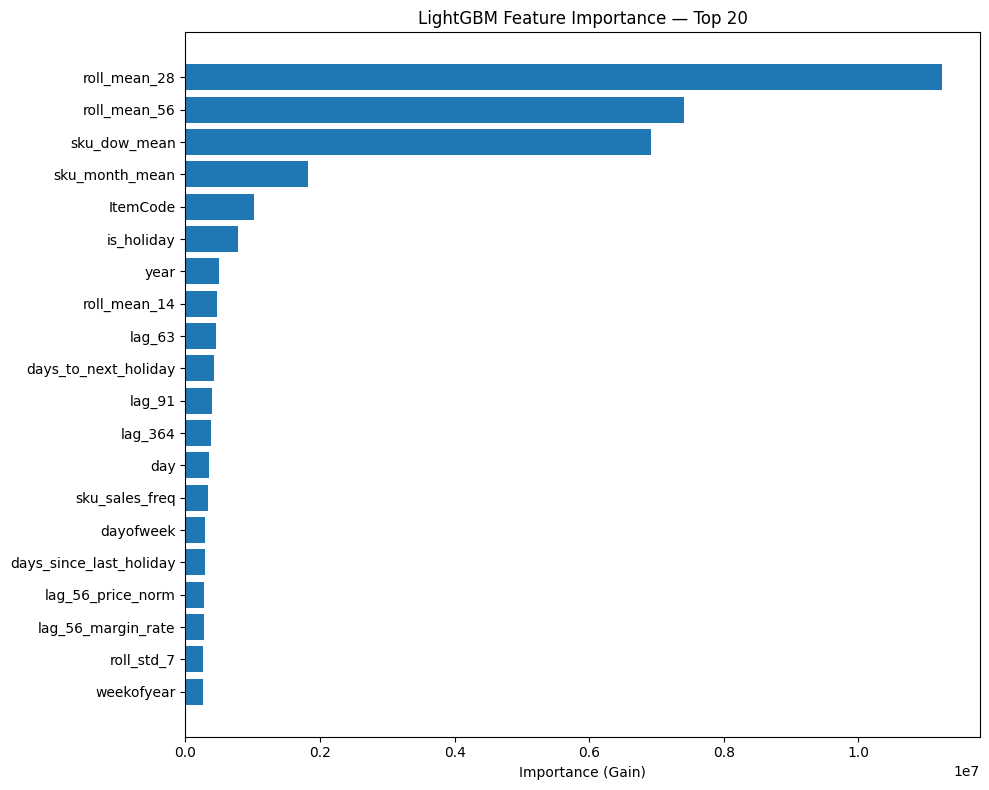

In [37]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature':    model.feature_name(),
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)
print('Top 20 features by gain:')
print(importance_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1])
ax.set_xlabel('Importance (Gain)')
ax.set_title('LightGBM Feature Importance — Top 20')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=120)
plt.show()

---
## 🔮 Cell 13 — 56-Day Multi-Step Forecasting

In [38]:
n_days_total   = daily['Date'].nunique()
sku_stats = (
    daily.groupby('ItemCode', observed=True)['Quantity']
    .agg(sku_mean_qty='mean', sku_std_qty='std').fillna(0).reset_index()
)
sku_sales_freq = (
    daily.groupby('ItemCode', observed=True)['Quantity']
         .apply(lambda x: (x > 0).sum() / n_days_total)
         .reset_index(name='sku_sales_freq')
)
sku_stats = sku_stats.merge(sku_sales_freq, on='ItemCode', how='left')
all_skus  = daily['ItemCode'].cat.categories.tolist()

all_forecast_dates = pd.date_range(VAL_START, EVAL_END, freq='D')
print(f'Forecast: {all_forecast_dates[0].date()} → {all_forecast_dates[-1].date()} ({len(all_forecast_dates)} days)')
print(f'Total inference: {len(all_skus):,} × {len(all_forecast_dates)} = {len(all_skus)*len(all_forecast_dates):,} rows')

Forecast: 2025-09-06 → 2025-10-31 (56 days)
Total inference: 15,972 × 56 = 894,432 rows


In [39]:
print('Generating optimized 56-day forecasts ...')
history_df = daily[daily['Date'] >= TRAIN_END - pd.Timedelta(days=400)][[
    'ItemCode', 'Date', 'Quantity', 'lag_56_price_norm', 
    'lag_56_is_discount', 'lag_56_margin_rate', 'lag_56_days_since_sale'
]].copy()

all_forecast_records = []
holiday_dates_sorted = sorted(VN_HOLIDAYS)
train_sums = daily.groupby('ItemCode')['Quantity'].sum().to_dict()
freq_map = daily.set_index('ItemCode')['sku_sales_freq'].to_dict()

# Map Mỏ neo
train_mask = daily['Date'] < SPLIT_DATE
sku_map = daily[train_mask].groupby('ItemCode', observed=True)['Quantity'].mean().to_dict()

last_price_norm_map = history_df.groupby('ItemCode')['lag_56_price_norm'].last().to_dict()
last_is_discount_map = history_df.groupby('ItemCode')['lag_56_is_discount'].last().to_dict()
last_margin_rate_map = history_df.groupby('ItemCode')['lag_56_margin_rate'].last().to_dict()
last_streak_map = history_df.groupby('ItemCode')['lag_56_days_since_sale'].last().to_dict()

for i, fdate in enumerate(all_forecast_dates):
    if (i + 1) % 10 == 0:
        print(f'  Day {i+1}/56: {fdate.date()}')
    hist_pivot = history_df.pivot(index='ItemCode', columns='Date', values='Quantity').fillna(0)
    
    future_hols = [h for h in holiday_dates_sorted if h > fdate]
    past_hols = [h for h in holiday_dates_sorted if h < fdate]
    days_to_next_hol = (future_hols[0] - fdate).days if future_hols else 365
    days_since_last_hol = (fdate - past_hols[-1]).days if past_hols else 365
    
    row_df = pd.DataFrame({'ItemCode': all_skus})
    
    for lag in [56, 63, 70, 84, 91, 364]:
        lag_date = fdate - pd.Timedelta(days=lag)
        row_df[f'lag_{lag}'] = row_df['ItemCode'].map(
            hist_pivot[lag_date] if lag_date in hist_pivot.columns else pd.Series(dtype=float)
        ).fillna(0).values
        
    lag56_date = fdate - pd.Timedelta(days=56)
    for window in [7, 14, 28, 56]:
        window_start = lag56_date - pd.Timedelta(days=window - 1)
        dates_in_win = [d for d in pd.date_range(window_start, lag56_date, freq='D') if d in hist_pivot.columns]
        if dates_in_win:
            win_vals = hist_pivot[dates_in_win].reindex(all_skus).fillna(0)
            row_df[f'roll_mean_{window}'] = win_vals.mean(axis=1).values
            row_df[f'roll_std_{window}']  = win_vals.std(axis=1).fillna(0).values
        else:
            row_df[f'roll_mean_{window}'] = 0.0
            row_df[f'roll_std_{window}']  = 0.0
            
    row_df['sku_sales_freq'] = row_df['ItemCode'].map(freq_map).fillna(0).values
    
    time_feats = {
        'dayofweek': fdate.dayofweek, 'day': fdate.day, 'month': fdate.month,
        'year': fdate.year, 'quarter': fdate.quarter, 'weekofyear': fdate.isocalendar()[1],
        'is_weekend': int(fdate.dayofweek >= 5), 'is_holiday': int(fdate in VN_HOLIDAYS),
        'days_to_next_holiday': days_to_next_hol,
        'days_since_last_holiday': days_since_last_hol,
        'is_pre_holiday_7d': 1 if (0 < days_to_next_hol <= 7) else 0,
        'is_post_holiday_3d': 1 if (0 < days_since_last_hol <= 3) else 0
    }
    for k, v in time_feats.items():
        row_df[k] = v
        
    row_df['sku_mean_qty'] = row_df['ItemCode'].map(sku_map).fillna(0).astype('float32')
    dow_keys = pd.MultiIndex.from_arrays([row_df['ItemCode'], row_df['dayofweek']])
    row_df['sku_dow_mean'] = dow_keys.map(dow_map).fillna(0).astype('float32')
    month_keys = pd.MultiIndex.from_arrays([row_df['ItemCode'], row_df['month']])
    row_df['sku_month_mean'] = month_keys.map(month_map).fillna(0).astype('float32')
    
    row_df['lag_56_price_norm'] = row_df['ItemCode'].map(last_price_norm_map).fillna(1.0).values
    row_df['lag_56_is_discount'] = row_df['ItemCode'].map(last_is_discount_map).fillna(0).values
    row_df['lag_56_margin_rate'] = row_df['ItemCode'].map(last_margin_rate_map).fillna(0).values
    row_df['lag_56_days_since_sale'] = row_df['ItemCode'].map(last_streak_map).fillna(0).values + i
    
    row_df['Date']     = fdate
    row_df['ItemCode'] = row_df['ItemCode'].astype('category')
    
    # 🌟 BÌNH PHƯƠNG DỰ BÁO
    preds = np.square(np.clip(model.predict(row_df[FEATURE_COLS], num_iteration=model.best_iteration), 0, None))
    row_df['forecast'] = preds
    
    row_df['train_sum'] = row_df['ItemCode'].map(train_sums).fillna(0.0)
    row_df.loc[row_df['train_sum'] == 0, 'forecast'] = 0.0
    row_df.loc[row_df['sku_sales_freq'] < 0.005, 'forecast'] = 0.0
    
    # 🌟 HẬU XỬ LÝ PHÂN TẦNG
    mask_tier1 = row_df['sku_mean_qty'] >= 15.0
    mask_tier2 = (row_df['sku_mean_qty'] >= 8.0) & (row_df['sku_mean_qty'] < 15.0)
    row_df.loc[mask_tier1, 'forecast'] = row_df.loc[mask_tier1, 'forecast'] * 1.25
    row_df.loc[mask_tier2, 'forecast'] = row_df.loc[mask_tier2, 'forecast'] * 1.12
    
    all_forecast_records.append(row_df[['ItemCode', 'Date', 'forecast']])

forecast_df = pd.concat(all_forecast_records, ignore_index=True)
print(f'Forecast complete: {len(forecast_df):,} rows')

Generating optimized 56-day forecasts ...
  Day 10/56: 2025-09-15
  Day 20/56: 2025-09-25
  Day 30/56: 2025-10-05
  Day 40/56: 2025-10-15
  Day 50/56: 2025-10-25
Forecast complete: 894,432 rows


---
## 📤 Cell 14 — Generate Submission File

In [40]:
sample_sub = pd.read_csv(SAMPLE_PATH)
print(f'Sample submission: {sample_sub.shape}  |  cols: {list(sample_sub.columns[:4])} ... {list(sample_sub.columns[-2:])}')
assert sample_sub.shape[1] == 29, f'Expected 29 cols (id + F1..F28), got {sample_sub.shape[1]}'
F_COLS     = [f'F{i}' for i in range(1, 29)]
val_dates  = pd.date_range(VAL_START,  VAL_END,  freq='D')   # 28 days
eval_dates = pd.date_range(EVAL_START, EVAL_END, freq='D')   # 28 days
assert len(val_dates) == 28 and len(eval_dates) == 28
fc_pivot = forecast_df.pivot(index='ItemCode', columns='Date', values='forecast').fillna(0)

submission_rows = []
for idx_row in sample_sub.itertuples(index=False):
    row_id = idx_row.id
    if '_validation' in row_id:
        sku, dates = row_id.replace('_validation', ''), val_dates
    elif '_evaluation' in row_id:
        sku, dates = row_id.replace('_evaluation', ''), eval_dates
    else:
        raise ValueError(f'Unexpected id format: {row_id}')
    preds_28 = np.clip(
        fc_pivot.loc[sku, dates].values if sku in fc_pivot.index else np.zeros(28), 0, None
    )
    if preds_28.mean() > 3.0:
        preds_28 = preds_28 * 1.08
        
    row = {'id': row_id}
    row.update({f'F{i+1}': preds_28[i] for i in range(28)})
    submission_rows.append(row)

submission = pd.DataFrame(submission_rows)

# Validation checks
assert len(submission) == len(sample_sub),            'Row count mismatch!'
assert set(submission['id']) == set(sample_sub['id']), 'ID set mismatch!'
assert submission[F_COLS].isna().sum().sum() == 0,     'NaN values found!'
assert (submission[F_COLS] < 0).sum().sum() == 0,      'Negative values found!'
assert submission['id'].duplicated().sum() == 0,        'Duplicate IDs found!'
print('✓ All validation checks passed!')

out_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)
flat = submission[F_COLS].values.flatten()
print(f'Saved  → {out_path}  ({out_path.stat().st_size/1024:.1f} KB)')
print(f'Stats  : mean={flat.mean():.3f}, median={np.median(flat):.3f}, % zero={(flat==0).mean()*100:.1f}%')

Sample submission: (31944, 29)  |  cols: ['id', 'F1', 'F2', 'F3'] ... ['F27', 'F28']
✓ All validation checks passed!
Saved  → /kaggle/working/submission.csv  (10635.0 KB)
Stats  : mean=0.022, median=0.000, % zero=58.0%


---
## 🧮 Cell 15 — Score Submission File (Local WRMSSE Evaluator)

Hàm `score_submission_file()` nhận vào **bất kỳ file CSV nào** theo định dạng submission
và tính WRMSSE dựa trên ground-truth thực tế từ tập training.

**Quy trình:**
1. Re-inference trên window cuối 56 ngày training → `submission_local_val.csv`
2. Tính WRMSSE + breakdown per SKU
3. Vẽ diagnostic dashboard 5 panel

> ⚠️ True Public/Private LB chỉ có thể tính bởi Kaggle. Đây là **local proxy score**.

In [41]:
def generate_local_val_submission(
    model, daily, feature_cols,
    split_date, train_end, vn_holidays, all_skus, output_path,
):
    local_dates = pd.date_range(split_date, train_end, freq='D')
    h           = len(local_dates)
    print(f'Generating local val: {local_dates[0].date()} -> {local_dates[-1].date()} ({h} days)')

    history_start = split_date - pd.Timedelta(days=400)
    hist_df       = daily[(daily['Date'] >= history_start) & (daily['Date'] < split_date)]\
                         [['ItemCode', 'Date', 'Quantity', 'lag_56_price_norm', 'lag_56_is_discount', 'lag_56_margin_rate', 'lag_56_days_since_sale']].copy()
    holiday_dates_sorted = sorted(vn_holidays)
    local_records        = []
    freq_map = daily.set_index('ItemCode')['sku_sales_freq'].to_dict()
    
    train_mask = daily['Date'] < split_date
    train_daily = daily[train_mask]
    
    sku_map   = train_daily.groupby('ItemCode', observed=True)['Quantity'].mean().to_dict()
    dow_map   = train_daily.groupby(['ItemCode', 'dayofweek'], observed=True)['Quantity'].mean().to_dict()
    month_map = train_daily.groupby(['ItemCode', 'month'], observed=True)['Quantity'].mean().to_dict()

    last_price_norm_map = hist_df.groupby('ItemCode')['lag_56_price_norm'].last().to_dict()
    last_is_discount_map = hist_df.groupby('ItemCode')['lag_56_is_discount'].last().to_dict()
    last_margin_rate_map = hist_df.groupby('ItemCode')['lag_56_margin_rate'].last().to_dict()
    last_streak_map = hist_df.groupby('ItemCode')['lag_56_days_since_sale'].last().to_dict()

    for i, fdate in enumerate(local_dates):
        if (i + 1) % 10 == 0:
            print(f'  Day {i+1}/{h}: {fdate.date()}')
        hist_pivot = hist_df.pivot(index='ItemCode', columns='Date', values='Quantity').fillna(0)
        
        future_hols = [hh for hh in holiday_dates_sorted if hh > fdate]
        past_hols = [hh for hh in holiday_dates_sorted if hh < fdate]
        days_to_next_hol = (future_hols[0] - fdate).days if future_hols else 365
        days_since_last_hol = (fdate - past_hols[-1]).days if past_hols else 365
        
        row_df = pd.DataFrame({'ItemCode': all_skus})
        
        for lag in [56, 63, 70, 84, 91, 364]:
            lag_date = fdate - pd.Timedelta(days=lag)
            row_df[f'lag_{lag}'] = row_df['ItemCode'].map(
                hist_pivot[lag_date] if lag_date in hist_pivot.columns else pd.Series(dtype=float)
            ).fillna(0).values
            
        lag56_date = fdate - pd.Timedelta(days=56)
        for window in [7, 14, 28, 56]:
            window_start = lag56_date - pd.Timedelta(days=window - 1)
            dates_in_win = [d for d in pd.date_range(window_start, lag56_date, freq='D')
                            if d in hist_pivot.columns]
            if dates_in_win:
                win_vals = hist_pivot[dates_in_win].reindex(all_skus).fillna(0)
                row_df[f'roll_mean_{window}'] = win_vals.mean(axis=1).values
                row_df[f'roll_std_{window}']  = win_vals.std(axis=1).fillna(0).values
            else:
                row_df[f'roll_mean_{window}'] = 0.0
                row_df[f'roll_std_{window}']  = 0.0
                
        row_df['sku_sales_freq'] = row_df['ItemCode'].map(freq_map).fillna(0).values
        
        time_feats = {
            'dayofweek': fdate.dayofweek, 'day': fdate.day, 'month': fdate.month,
            'year': fdate.year, 'quarter': fdate.quarter, 'weekofyear': fdate.isocalendar()[1],
            'is_weekend': int(fdate.dayofweek >= 5), 'is_holiday': int(fdate in vn_holidays),
            'days_to_next_holiday': days_to_next_hol,
            'days_since_last_holiday': days_since_last_hol,
            'is_pre_holiday_7d': 1 if (0 < days_to_next_hol <= 7) else 0,
            'is_post_holiday_3d': 1 if (0 < days_since_last_hol <= 3) else 0
        }
        for k, v in time_feats.items():
            row_df[k] = v
            
        row_df['sku_mean_qty'] = row_df['ItemCode'].map(sku_map).fillna(0).astype('float32')
        dow_keys = pd.MultiIndex.from_arrays([row_df['ItemCode'], row_df['dayofweek']])
        row_df['sku_dow_mean'] = dow_keys.map(dow_map).fillna(0).astype('float32')
        month_keys = pd.MultiIndex.from_arrays([row_df['ItemCode'], row_df['month']])
        row_df['sku_month_mean'] = month_keys.map(month_map).fillna(0).astype('float32')
        
        row_df['lag_56_price_norm'] = row_df['ItemCode'].map(last_price_norm_map).fillna(1.0).values
        row_df['lag_56_is_discount'] = row_df['ItemCode'].map(last_is_discount_map).fillna(0).values
        row_df['lag_56_margin_rate'] = row_df['ItemCode'].map(last_margin_rate_map).fillna(0).values
        row_df['lag_56_days_since_sale'] = row_df['ItemCode'].map(last_streak_map).fillna(0).values + i
            
        row_df['Date']     = fdate
        row_df['ItemCode'] = row_df['ItemCode'].astype('category')
        
        # 🌟 BÌNH PHƯƠNG DỰ BÁO
        preds = np.square(np.clip(model.predict(row_df[feature_cols], num_iteration=model.best_iteration), 0, None))
        row_df['forecast'] = preds
        
        # 🌟 HẬU XỬ LÝ PHÂN TẦNG
        mask_tier1 = row_df['sku_mean_qty'] >= 15.0
        mask_tier2 = (row_df['sku_mean_qty'] >= 8.0) & (row_df['sku_mean_qty'] < 15.0)
        row_df.loc[mask_tier1, 'forecast'] = row_df.loc[mask_tier1, 'forecast'] * 1.25
        row_df.loc[mask_tier2, 'forecast'] = row_df.loc[mask_tier2, 'forecast'] * 1.12
        
        local_records.append(row_df[['ItemCode', 'Date', 'forecast']])

    local_fc = pd.concat(local_records, ignore_index=True)
    fc_pivot = local_fc.pivot(index='ItemCode', columns='Date', values='forecast').fillna(0)
    rows = []
    for sku in all_skus:
        vals = fc_pivot.loc[sku, local_dates].values if sku in fc_pivot.index else np.zeros(h)
        row  = {'id': f'{sku}_local_val'}
        row.update({f'F{i+1}': float(vals[i]) for i in range(h)})
        rows.append(row)
    result_df = pd.DataFrame(rows)
    result_df.to_csv(output_path, index=False)
    print(f'Saved -> {output_path}  ({output_path.stat().st_size/1024:.0f} KB)')
    return result_df

In [42]:
def score_submission_file(
    submission_path, daily, sku_profit,
    eval_start=SPLIT_DATE, eval_end=TRAIN_END,
    suffix='_local_val', verbose=True,
):
    """
    Score a submission CSV against ground truth from training data.

    Parameters
    ----------
    submission_path : str | Path
        Submission CSV with columns: id | F1 | ... | F<h>
        where id ends with `suffix`.
    daily : pd.DataFrame
        Full reindexed daily frame (ItemCode x Date x Quantity).
    sku_profit : pd.DataFrame
        ['ItemCode', 'total_profit', 'weight']
    eval_start / eval_end : pd.Timestamp
        Ground-truth window — must be within training data date range.
    suffix : str
        Suffix in id column identifying which rows to score.
    verbose : bool
        Print detailed output.

    Returns
    -------
    dict: {'wrmsse', 'rmsse_df', 'n_skus', 'n_zero_weight'}
    """
    sub          = pd.read_csv(submission_path)
    sub_filtered = sub[sub['id'].str.endswith(suffix)].copy()
    if len(sub_filtered) == 0:
        available = sub['id'].str.extract(r'(_[^_]+)$')[0].unique().tolist()
        raise ValueError(f"No rows with suffix '{suffix}'. Available: {available}")

    sub_filtered['ItemCode'] = sub_filtered['id'].str.replace(suffix, '', regex=False)
    f_cols = sorted([c for c in sub_filtered.columns if c.startswith('F') and c[1:].isdigit()],
                    key=lambda x: int(x[1:]))
    h          = len(f_cols)
    eval_dates = pd.date_range(eval_start, periods=h, freq='D')
    sku_order  = sub_filtered['ItemCode'].tolist()

    if verbose:
        print(f'Scoring {len(sku_order):,} SKUs | {h} days | {eval_dates[0].date()} → {eval_dates[-1].date()}')

    gt       = daily[daily['Date'].isin(eval_dates)][['ItemCode', 'Date', 'Quantity']].copy()
    gt_pivot = gt.pivot(index='ItemCode', columns='Date', values='Quantity').fillna(0)
    gt_pivot = gt_pivot.reindex(sku_order).fillna(0)
    true_matrix = gt_pivot[eval_dates].values.astype(float)

    sub_filtered = sub_filtered.set_index('ItemCode')
    pred_matrix  = sub_filtered[f_cols].reindex(sku_order).fillna(0).values.astype(float)

    train_hist  = daily[daily['Date'] < eval_start][['ItemCode', 'Date', 'Quantity']]
    train_pivot = (
        train_hist.pivot(index='ItemCode', columns='Date', values='Quantity')
        .reindex(sku_order).fillna(0).values.astype(float)
    )

    eps           = 1e-9
    naive_sq_err  = np.diff(train_pivot, axis=1) ** 2
    denom         = naive_sq_err.mean(axis=1)
    mse_forecast  = ((true_matrix - pred_matrix) ** 2).mean(axis=1)
    rmsse_per_sku = np.sqrt(mse_forecast / (denom + eps))

    weight_map = sku_profit.set_index('ItemCode')['weight'].to_dict()
    weights    = np.array([weight_map.get(s, 0.0) for s in sku_order])
    if weights.sum() > 0:
        weights = weights / weights.sum()

    wrmsse = float(np.sum(weights * rmsse_per_sku))

    rmsse_df = pd.DataFrame({
        'ItemCode':       sku_order,
        'rmsse':          rmsse_per_sku,
        'weight':         weights,
        'weighted_rmsse': weights * rmsse_per_sku,
        'mean_actual':    true_matrix.mean(axis=1),
        'mean_pred':      pred_matrix.mean(axis=1),
        'mae':            np.abs(true_matrix - pred_matrix).mean(axis=1),
    }).sort_values('weighted_rmsse', ascending=False).reset_index(drop=True)

    n_zero_weight = int((weights == 0).sum())
    weighted_skus = rmsse_df[rmsse_df['weight'] > 0]

    if verbose:
        sep    = '=' * 60
        better = wrmsse < 1
        print(f'\n{sep}')
        print(f'  WRMSSE Score          :  {wrmsse:.6f}')
        print(f'  Naive baseline        :  1.000000')
        print(f'  vs Naive              :  {"BETTER" if better else "WORSE"} ({wrmsse-1:+.4f})')
        print(f'{sep}')
        print(f'  SKUs total            : {len(sku_order):,}')
        print(f'  SKUs with weight > 0  : {len(weighted_skus):,}')
        print(f'  SKUs with weight = 0  : {n_zero_weight:,}  (zero-profit)')
        print(f'  Median RMSSE (w>0)    : {weighted_skus["rmsse"].median():.4f}')
        print(f'  % SKUs RMSSE < 1.0    : {(weighted_skus["rmsse"] < 1.0).mean()*100:.1f}%')
        print(f'  % SKUs RMSSE < 0.5    : {(weighted_skus["rmsse"] < 0.5).mean()*100:.1f}%')
        print(f'{sep}\n')
        print('Top 10 SKUs by WRMSSE contribution (worst performers):')
        print(weighted_skus.head(10)[
            ['ItemCode', 'rmsse', 'weight', 'weighted_rmsse', 'mean_actual', 'mean_pred']
        ].to_string(index=False))
        print('\nTop 5 best performers (lowest weighted RMSSE):')
        print(weighted_skus.tail(5)[
            ['ItemCode', 'rmsse', 'weight', 'weighted_rmsse', 'mean_actual', 'mean_pred']
        ].to_string(index=False))

    return {'wrmsse': wrmsse, 'rmsse_df': rmsse_df, 'n_skus': len(sku_order), 'n_zero_weight': n_zero_weight}


print('score_submission_file() defined ✓')

score_submission_file() defined ✓


In [43]:
print('=' * 60)
print('STEP 1: Generating local validation predictions')
print('=' * 60)
local_sub_path = OUTPUT_DIR / 'submission_local_val.csv'
local_sub_df = generate_local_val_submission(
    model        = model,
    daily        = daily,
    feature_cols = FEATURE_COLS,
    split_date   = SPLIT_DATE,
    train_end    = TRAIN_END,
    vn_holidays  = VN_HOLIDAYS,
    all_skus     = all_skus,
    output_path  = local_sub_path,
)

print(f'\n{"=" * 60}')
print('STEP 2: Scoring against training ground truth')
print('=' * 60)
results = score_submission_file(
    submission_path = str(local_sub_path),
    daily           = daily,
    sku_profit      = sku_profit_val,
    eval_start      = SPLIT_DATE,
    eval_end        = TRAIN_END,
    suffix          = '_local_val',
    verbose         = True,
)

STEP 1: Generating local validation predictions
Generating local val: 2025-07-12 -> 2025-09-05 (56 days)
  Day 10/56: 2025-07-21
  Day 20/56: 2025-07-31
  Day 30/56: 2025-08-10
  Day 40/56: 2025-08-20
  Day 50/56: 2025-08-30
Saved -> /kaggle/working/submission_local_val.csv  (19439 KB)

STEP 2: Scoring against training ground truth
Scoring 15,972 SKUs | 56 days | 2025-07-12 → 2025-09-05

  WRMSSE Score          :  0.561786
  Naive baseline        :  1.000000
  vs Naive              :  BETTER (-0.4382)
  SKUs total            : 15,972
  SKUs with weight > 0  : 13,780
  SKUs with weight = 0  : 2,192  (zero-profit)
  Median RMSSE (w>0)    : 0.0020
  % SKUs RMSSE < 1.0    : 86.6%
  % SKUs RMSSE < 0.5    : 79.0%

Top 10 SKUs by WRMSSE contribution (worst performers):
 ItemCode  rmsse  weight  weighted_rmsse  mean_actual  mean_pred
SKU-00003 1.3785  0.0909          0.1252      11.2143     6.4367
SKU-00002 1.1044  0.0432          0.0478       5.7857     3.9759
SKU-14323 1.9078  0.0054        

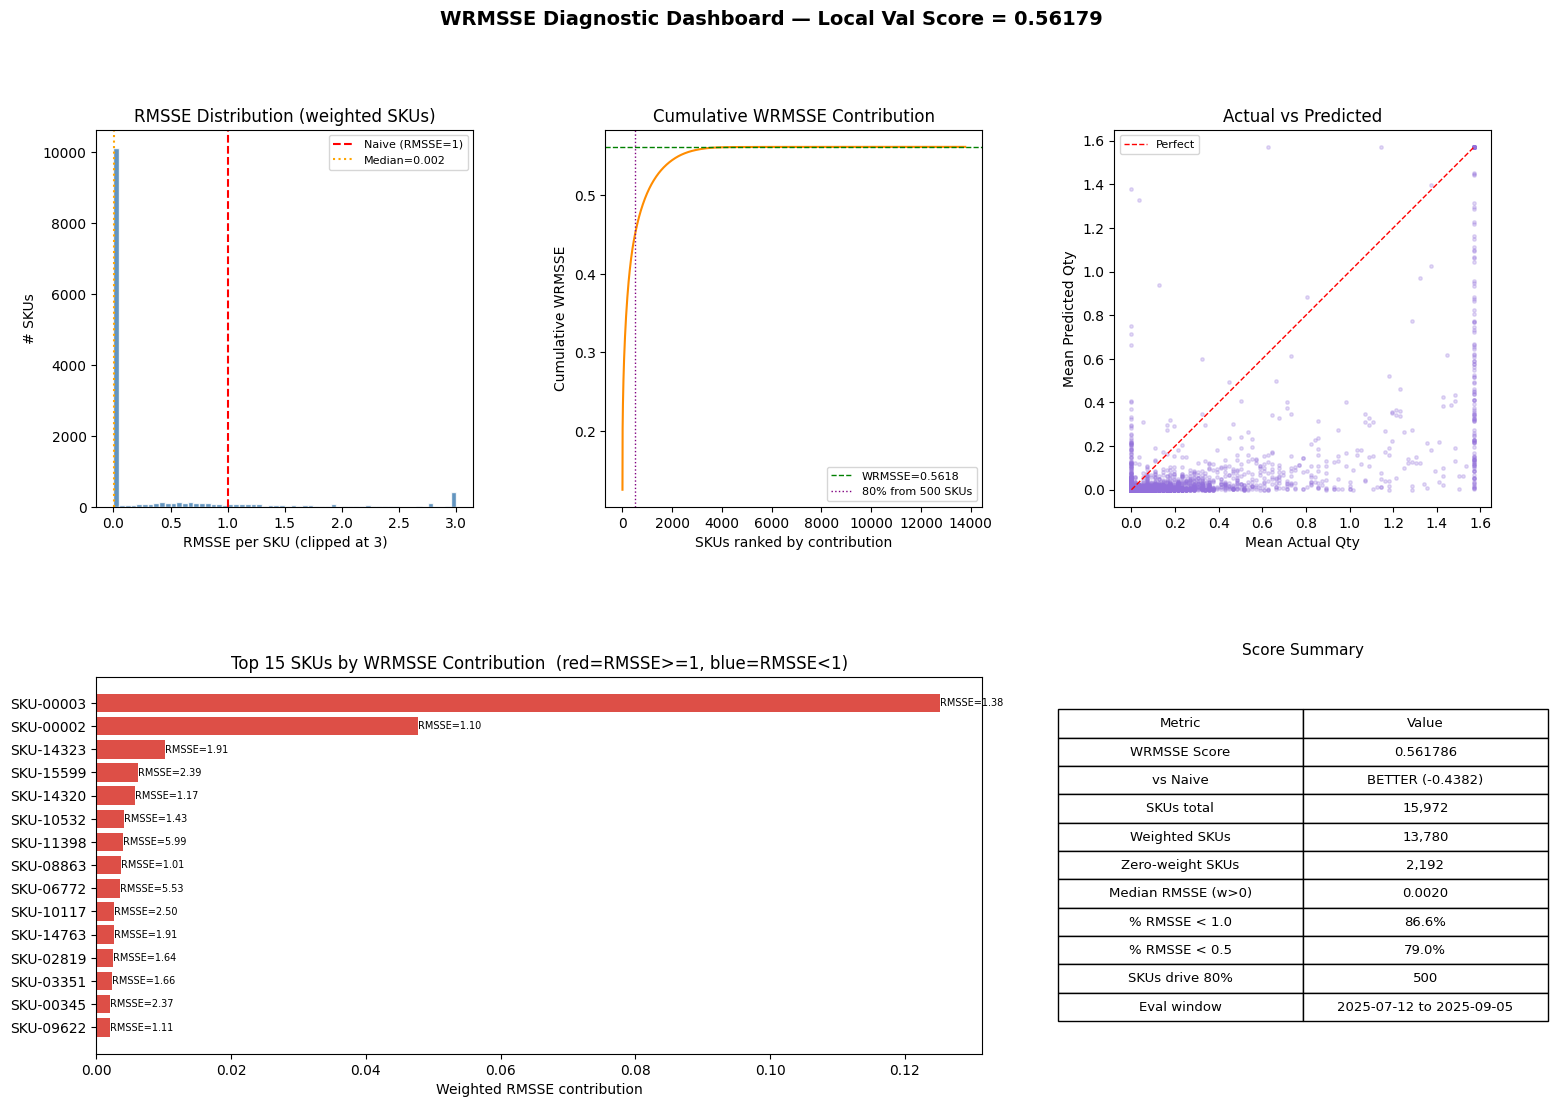

Chart saved → /kaggle/working/wrmsse_analysis.png


In [44]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rmsse_df   = results['rmsse_df']
weighted   = rmsse_df[rmsse_df['weight'] > 0].copy()
wrmsse_val = results['wrmsse']

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(weighted['rmsse'].clip(upper=3), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(1.0, color='red', linestyle='--', lw=1.5, label='Naive (RMSSE=1)')
ax1.axvline(weighted['rmsse'].median(), color='orange', linestyle=':', lw=1.5,
            label=f'Median={weighted["rmsse"].median():.3f}')
ax1.set_xlabel('RMSSE per SKU (clipped at 3)')
ax1.set_ylabel('# SKUs')
ax1.set_title('RMSSE Distribution (weighted SKUs)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
sorted_contrib = weighted.sort_values('weighted_rmsse', ascending=False)['weighted_rmsse'].cumsum()
n_to_80 = int((sorted_contrib <= 0.8 * wrmsse_val).sum()) + 1
ax2.plot(range(1, len(sorted_contrib)+1), sorted_contrib.values, color='darkorange', lw=1.5)
ax2.axhline(wrmsse_val, color='green', linestyle='--', lw=1, label=f'WRMSSE={wrmsse_val:.4f}')
ax2.axvline(n_to_80, color='purple', linestyle=':', lw=1, label=f'80% from {n_to_80} SKUs')
ax2.set_xlabel('SKUs ranked by contribution')
ax2.set_ylabel('Cumulative WRMSSE')
ax2.set_title('Cumulative WRMSSE Contribution')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[0, 2])
q99 = max(weighted['mean_actual'].quantile(0.99), weighted['mean_pred'].quantile(0.99))
ax3.scatter(weighted['mean_actual'].clip(upper=q99), weighted['mean_pred'].clip(upper=q99),
            alpha=0.25, s=6, color='mediumpurple')
ax3.plot([0, q99], [0, q99], 'r--', lw=1, label='Perfect')
ax3.set_xlabel('Mean Actual Qty')
ax3.set_ylabel('Mean Predicted Qty')
ax3.set_title('Actual vs Predicted')
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 0:2])
top15  = weighted.head(15).copy()
colors = ['#d73027' if r >= 1 else '#4575b4' for r in top15['rmsse']]
bars   = ax4.barh(top15['ItemCode'][::-1], top15['weighted_rmsse'][::-1], color=colors[::-1], alpha=0.85)
ax4.set_xlabel('Weighted RMSSE contribution')
ax4.set_title('Top 15 SKUs by WRMSSE Contribution  (red=RMSSE>=1, blue=RMSSE<1)')
for bar, r in zip(bars, top15['rmsse'][::-1]):
    ax4.text(bar.get_width() + 1e-6, bar.get_y() + bar.get_height()/2,
             f'RMSSE={r:.2f}', va='center', ha='left', fontsize=7)

ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
better = wrmsse_val < 1
summary_data = [
    ['WRMSSE Score',       f'{wrmsse_val:.6f}'],
    ['vs Naive',           f'{"BETTER" if better else "WORSE"} ({wrmsse_val-1:+.4f})'],
    ['SKUs total',         f'{results["n_skus"]:,}'],
    ['Weighted SKUs',      f'{results["n_skus"] - results["n_zero_weight"]:,}'],
    ['Zero-weight SKUs',   f'{results["n_zero_weight"]:,}'],
    ['Median RMSSE (w>0)', f'{weighted["rmsse"].median():.4f}'],
    ['% RMSSE < 1.0',      f'{(weighted["rmsse"] < 1.0).mean()*100:.1f}%'],
    ['% RMSSE < 0.5',      f'{(weighted["rmsse"] < 0.5).mean()*100:.1f}%'],
    ['SKUs drive 80%',     f'{n_to_80}'],
    ['Eval window',        f'{SPLIT_DATE.date()} to {TRAIN_END.date()}'],
]
tbl = ax5.table(cellText=summary_data, colLabels=['Metric', 'Value'], cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.3, 1.7)
ax5.set_title('Score Summary', fontsize=11, pad=16)

fig.suptitle(f'WRMSSE Diagnostic Dashboard — Local Val Score = {wrmsse_val:.5f}',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'wrmsse_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Chart saved → {OUTPUT_DIR / "wrmsse_analysis.png"}')

In [45]:
print(f'Local val WRMSSE = {results["wrmsse"]:.6f}')
print('\nTop 5 worst SKUs by weighted RMSSE:')
print(results['rmsse_df'][results['rmsse_df']['weight'] > 0]
      .head(5)[['ItemCode', 'rmsse', 'weight', 'weighted_rmsse', 'mean_actual', 'mean_pred']]
      .to_string(index=False))
print('\nFiles generated:')
for p in sorted(OUTPUT_DIR.glob('*.csv')) + sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

Local val WRMSSE = 0.561786

Top 5 worst SKUs by weighted RMSSE:
 ItemCode  rmsse  weight  weighted_rmsse  mean_actual  mean_pred
SKU-00003 1.3785  0.0909          0.1252      11.2143     6.4367
SKU-00002 1.1044  0.0432          0.0478       5.7857     3.9759
SKU-14323 1.9078  0.0054          0.0102      23.6964     5.4602
SKU-15599 2.3864  0.0026          0.0062      26.1964     5.0531
SKU-14320 1.1664  0.0049          0.0058      17.0179     5.3713

Files generated:
  submission.csv  (10635.0 KB)
  submission_local_val.csv  (19439.2 KB)
  feature_importance.png  (64.0 KB)
  wrmsse_analysis.png  (274.6 KB)


---
## 🏁 Done!

**Files generated:**
| File | Description |
|:---|:---|
| `submission.csv` | Main competition submission (upload to Kaggle) |
| `submission_local_val.csv` | Local validation predictions for WRMSSE scoring |
| `feature_importance.png` | LightGBM feature importance (Gain) chart |
| `wrmsse_analysis.png` | 5-panel WRMSSE diagnostic dashboard |

**Pipeline summary:**
1. Load `train.csv` — `Stt` as str (mixed int/code), int cols cast via `pd.to_numeric`, VND string cols via `parse_vnd()`
2. Compute profit-based WRMSSE weights per SKU (clip negative → 0)
3. Net-aggregate returns into daily demand, clip net < 0 → 0
4. Reindex to full daily calendar (15,972 SKUs x ~1,753 days)
5. Engineer leak-free lag (>=56d) + rolling features + holiday + SKU stats
6. Train global LightGBM (Tweedie loss) with early stopping
7. Evaluate locally via WRMSSE on last 56-day hold-out
8. Generate 56-day forecasts day-by-day (no recursive, no leakage)
9. Export `submission.csv` with 31,944 rows x 29 columns
10. Score output with `score_submission_file()` + WRMSSE diagnostic dashboard